# Customer Churn Analysis & Prediction

## Project Overview

This project analyzes customer churn using data analysis and machine learning techniques. The objective is to identify the major factors associated with customer churn and develop a machine learning model to predict customers who are at risk of leaving.

### Objectives

- Analyze customer behavior and churn patterns
- Identify factors associated with customer churn
- Perform exploratory data analysis (EDA)
- Calculate and visualize churn rates
- Analyze correlations between numerical variables
- Build and compare machine learning classification models
- Evaluate models using Accuracy, Classification Report, and ROC-AUC
- Identify important features influencing churn
- Provide actionable business recommendations

### Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- Google Colab

### Machine Learning Models

- Logistic Regression
- Scaled Logistic Regression
- Random Forest Classifier

### Key Result

The best-performing model was **Logistic Regression**, achieving:

- **Accuracy:** 57.25%
- **ROC-AUC:** 0.600

The analysis identified **LastPurchaseDaysAgo** as the most influential feature associated with customer churn.

In [47]:
# Customer Churn Analysis
# End-to-End Data Analytics & Machine Learning Project

# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve
)

print("Libraries imported successfully!")

Libraries imported successfully!


In [48]:
# Step 2: Load the dataset

from google.colab import files

uploaded = files.upload()

Saving customer_churn (1).csv to customer_churn (1) (2).csv


In [49]:
# Step 3: Load the dataset into a DataFrame

df = pd.read_csv("customer_churn (1).csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (2000, 9)


,CustomerID,Age,MembershipDuration,AvgMonthlySpend,NumPurchasesLast3Months,SupportTicketsRaised,DiscountUsageRate,LastPurchaseDaysAgo,Churned
0,C0001,56,17,189.05,2,3,43.64,95,0
1,C0002,69,44,387.53,3,2,65.48,69,1
2,C0003,46,56,174.29,4,1,70.03,114,1
3,C0004,32,28,514.01,4,2,86.31,104,0
4,C0005,60,29,412.37,5,2,18.05,108,0


In [50]:
# Step 4: Understand the dataset

print("Column Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nDataset Information:")
df.info()

Column Names:
['CustomerID', 'Age', 'MembershipDuration', 'AvgMonthlySpend', 'NumPurchasesLast3Months', 'SupportTicketsRaised', 'DiscountUsageRate', 'LastPurchaseDaysAgo', 'Churned']

Data Types:
CustomerID                  object
Age                          int64
MembershipDuration           int64
AvgMonthlySpend            float64
NumPurchasesLast3Months      int64
SupportTicketsRaised         int64
DiscountUsageRate          float64
LastPurchaseDaysAgo          int64
Churned                      int64
dtype: object

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   CustomerID               2000 non-null   object 
 1   Age                      2000 non-null   int64  
 2   MembershipDuration       2000 non-null   int64  
 3   AvgMonthlySpend          2000 non-null   float64
 4   NumPurchasesLast3M

In [51]:
# Step 5: Check for missing values and duplicate records

print("Missing Values:")
print(df.isnull().sum())

print("\nTotal Missing Values:", df.isnull().sum().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

Missing Values:
CustomerID                 0
Age                        0
MembershipDuration         0
AvgMonthlySpend            0
NumPurchasesLast3Months    0
SupportTicketsRaised       0
DiscountUsageRate          0
LastPurchaseDaysAgo        0
Churned                    0
dtype: int64

Total Missing Values: 0

Duplicate Rows: 0


In [52]:
# Step 6: Check Churn Distribution

print("Churn Distribution:")
print(df["Churned"].value_counts())

print("\nChurn Percentage:")
print(df["Churned"].value_counts(normalize=True) * 100)

Churn Distribution:
Churned
1    1133
0     867
Name: count, dtype: int64

Churn Percentage:
Churned
1    56.65
0    43.35
Name: proportion, dtype: float64


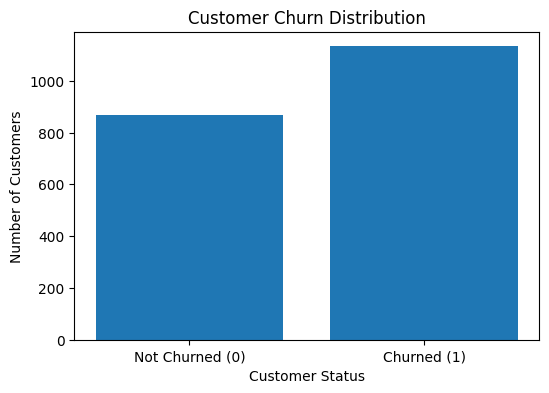

In [53]:
# Step 7: Visualize Churn Distribution

import matplotlib.pyplot as plt

churn_counts = df["Churned"].value_counts()

plt.figure(figsize=(6, 4))
plt.bar(["Not Churned (0)", "Churned (1)"],
        [churn_counts[0], churn_counts[1]])

plt.title("Customer Churn Distribution")
plt.xlabel("Customer Status")
plt.ylabel("Number of Customers")
plt.show()

In [54]:
# Calculate Churn Rate

total_customers = churn_counts[0] + churn_counts[1]
churn_rate = (churn_counts[1] / total_customers) * 100

print("Total Customers:", total_customers)
print("Churned Customers:", churn_counts[1])
print("Not Churned Customers:", churn_counts[0])
print("Churn Rate: {:.2f}%".format(churn_rate))

Total Customers: 2000
Churned Customers: 1133
Not Churned Customers: 867
Churn Rate: 56.65%


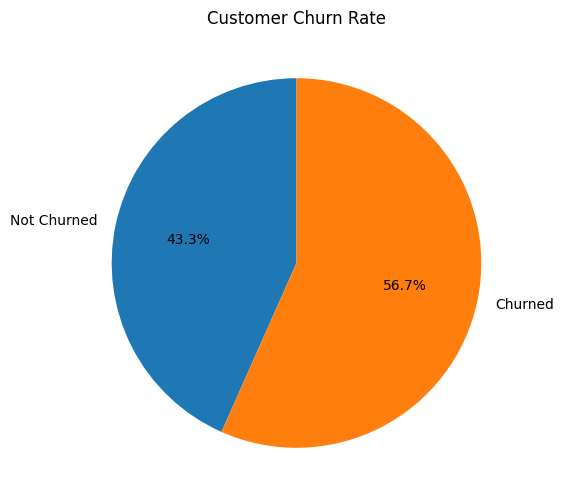

In [55]:
# Churn Rate Visualization

labels = ["Not Churned", "Churned"]
sizes = [churn_counts[0], churn_counts[1]]

plt.figure(figsize=(6, 6))
plt.pie(
    sizes,
    labels=labels,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Customer Churn Rate")
plt.show()

In [56]:
print(df.columns.tolist())

['CustomerID', 'Age', 'MembershipDuration', 'AvgMonthlySpend', 'NumPurchasesLast3Months', 'SupportTicketsRaised', 'DiscountUsageRate', 'LastPurchaseDaysAgo', 'Churned']


Churned            0    1
MembershipGroup          
0-6 Months        84  119
7-12 Months       84  116
13-24 Months     194  231
24+ Months       505  667


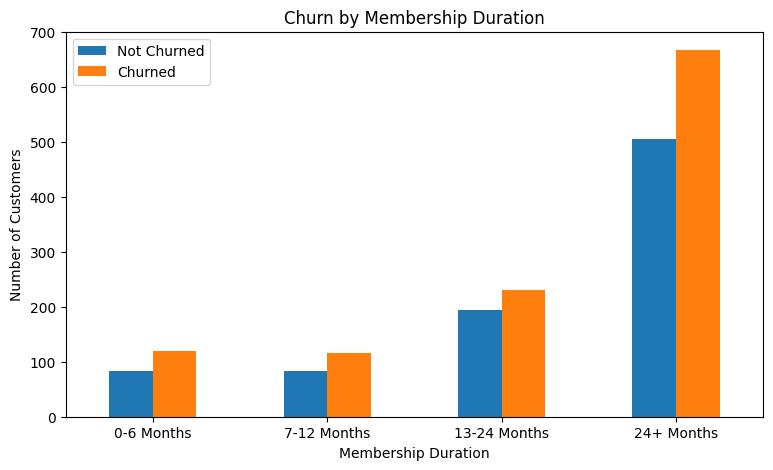

In [57]:
# Churn by Membership Duration

df["MembershipGroup"] = pd.cut(
    df["MembershipDuration"],
    bins=[0, 6, 12, 24, 100],
    labels=["0-6 Months", "7-12 Months", "13-24 Months", "24+ Months"]
)

membership_churn = pd.crosstab(
    df["MembershipGroup"],
    df["Churned"]
)

print(membership_churn)

membership_churn.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Churn by Membership Duration")
plt.xlabel("Membership Duration")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.legend(["Not Churned", "Churned"])
plt.show()

Churned
0    396.170830
1    404.053372
Name: AvgMonthlySpend, dtype: float64


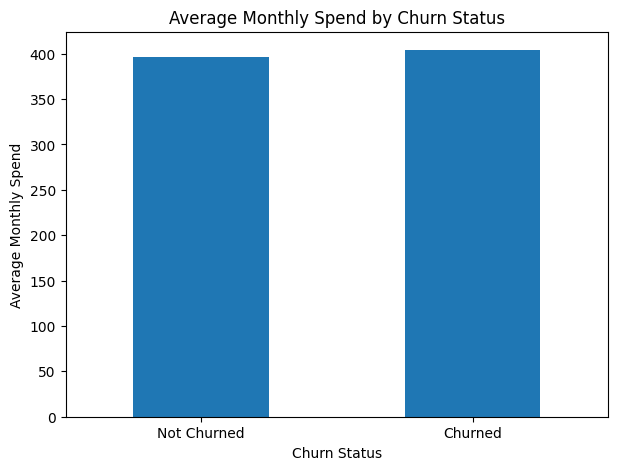

In [58]:
# Churn by Average Monthly Spend

spend_churn = df.groupby("Churned")["AvgMonthlySpend"].mean()

print(spend_churn)

spend_churn.plot(
    kind="bar",
    figsize=(7, 5)
)

plt.title("Average Monthly Spend by Churn Status")
plt.xlabel("Churn Status")
plt.ylabel("Average Monthly Spend")
plt.xticks([0, 1], ["Not Churned", "Churned"], rotation=0)
plt.show()

Churned                 0    1
SupportTicketsRaised          
0                     185  229
1                     282  340
2                     222  316
3                     122  148
4                      40   64
5                      11   25
6                       4    8
7                       1    1
8                       0    2


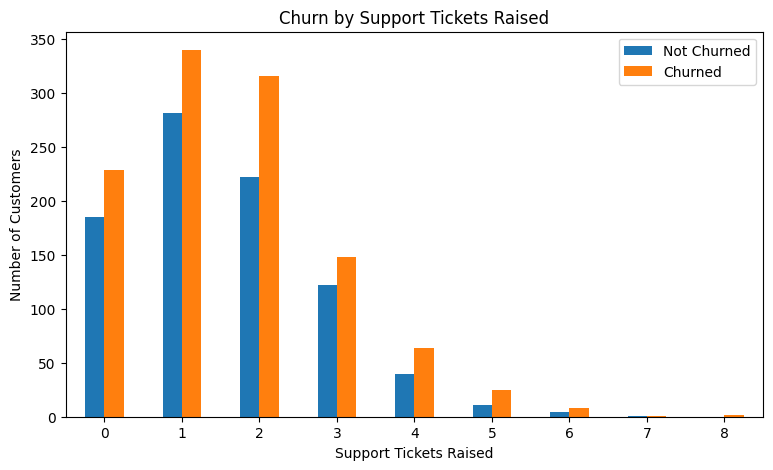

In [59]:
# Churn by Support Tickets Raised

support_churn = pd.crosstab(
    df["SupportTicketsRaised"],
    df["Churned"]
)

print(support_churn)

support_churn.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Churn by Support Tickets Raised")
plt.xlabel("Support Tickets Raised")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.legend(["Not Churned", "Churned"])
plt.show()

Churned                       0           1
SupportTicketsRaised                       
0                     44.685990   55.314010
1                     45.337621   54.662379
2                     41.263941   58.736059
3                     45.185185   54.814815
4                     38.461538   61.538462
5                     30.555556   69.444444
6                     33.333333   66.666667
7                     50.000000   50.000000
8                      0.000000  100.000000


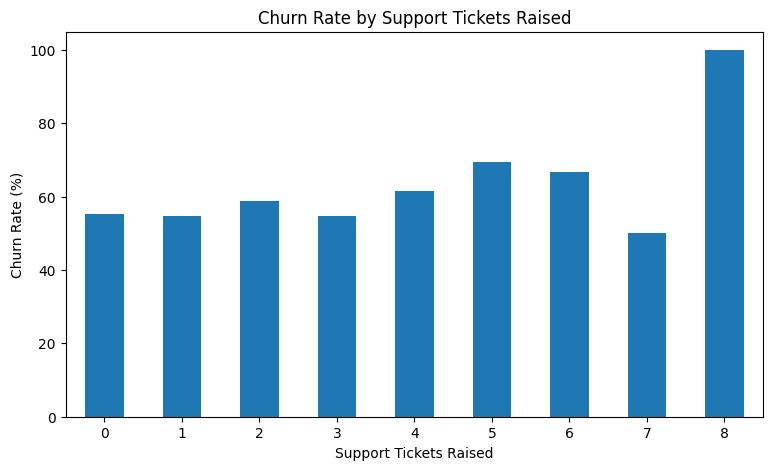

In [60]:
# Churn Rate by Support Tickets

support_churn_rate = pd.crosstab(
    df["SupportTicketsRaised"],
    df["Churned"],
    normalize="index"
) * 100

print(support_churn_rate)

support_churn_rate[1].plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Churn Rate by Support Tickets Raised")
plt.xlabel("Support Tickets Raised")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()

Churned                 0    1
PurchaseRecencyGroup          
0-30 Days             195  143
31-60 Days            158  158
61-90 Days            149  199
91-180 Days           365  633


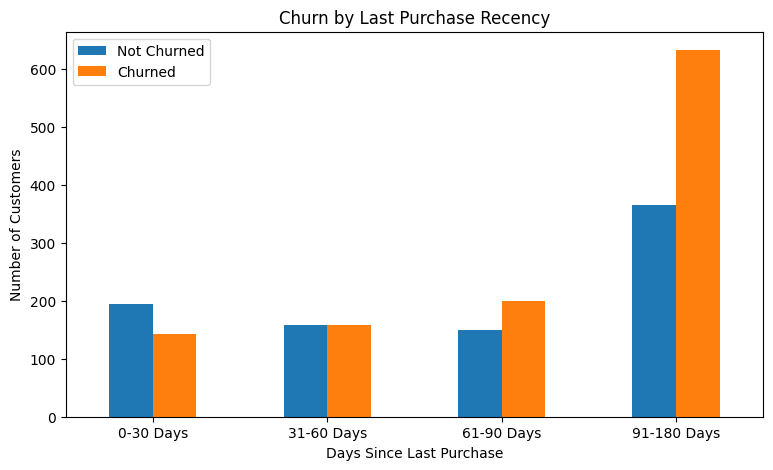

In [61]:
# Churn by Last Purchase Recency

df["PurchaseRecencyGroup"] = pd.cut(
    df["LastPurchaseDaysAgo"],
    bins=[0, 30, 60, 90, 180, 1000],
    labels=[
        "0-30 Days",
        "31-60 Days",
        "61-90 Days",
        "91-180 Days",
        "180+ Days"
    ]
)

recency_churn = pd.crosstab(
    df["PurchaseRecencyGroup"],
    df["Churned"]
)

print(recency_churn)

recency_churn.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Churn by Last Purchase Recency")
plt.xlabel("Days Since Last Purchase")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.legend(["Not Churned", "Churned"])
plt.show()

Churned     0    1
AgeGroup          
18-25     125  170
26-35     155  198
36-45     151  229
46-55     189  221
56+       247  315


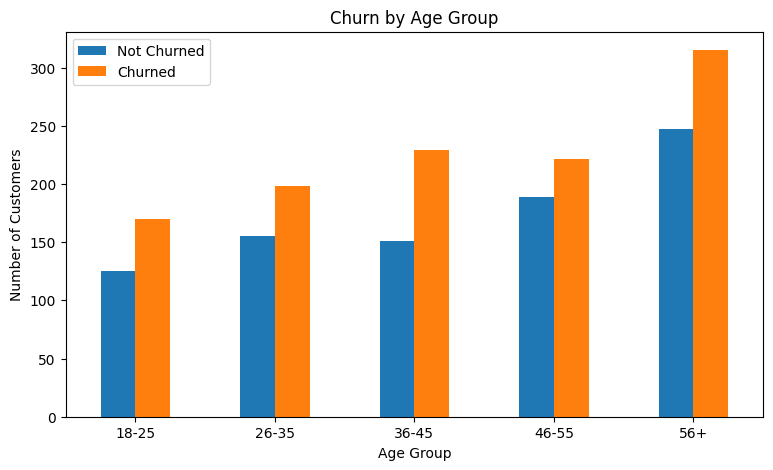

In [62]:
# Churn by Age Group

df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=[0, 25, 35, 45, 55, 100],
    labels=[
        "18-25",
        "26-35",
        "36-45",
        "46-55",
        "56+"
    ]
)

age_churn = pd.crosstab(
    df["AgeGroup"],
    df["Churned"]
)

print(age_churn)

age_churn.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Churn by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.legend(["Not Churned", "Churned"])
plt.show()

Churned           0          1
AgeGroup                      
18-25     42.372881  57.627119
26-35     43.909348  56.090652
36-45     39.736842  60.263158
46-55     46.097561  53.902439
56+       43.950178  56.049822


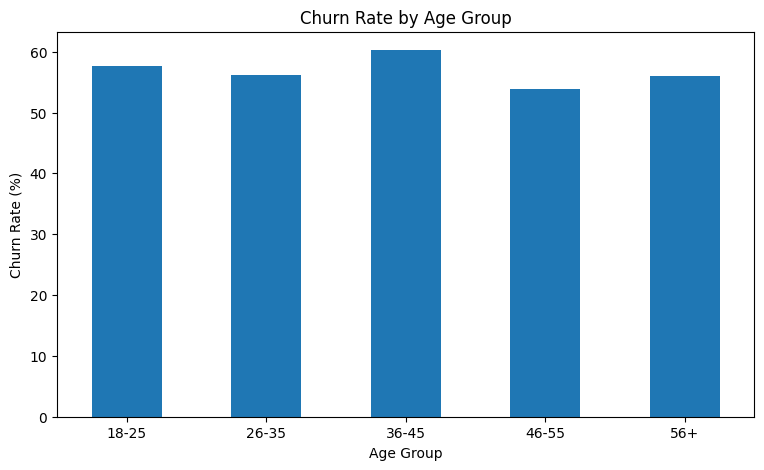

In [63]:
# Churn Rate by Age Group

age_churn_rate = pd.crosstab(
    df["AgeGroup"],
    df["Churned"],
    normalize="index"
) * 100

print(age_churn_rate)

age_churn_rate[1].plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Churn Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()

Churned          0    1
DiscountGroup          
0-25%          196  266
26-50%         212  282
51-75%         214  293
76-100%        245  292


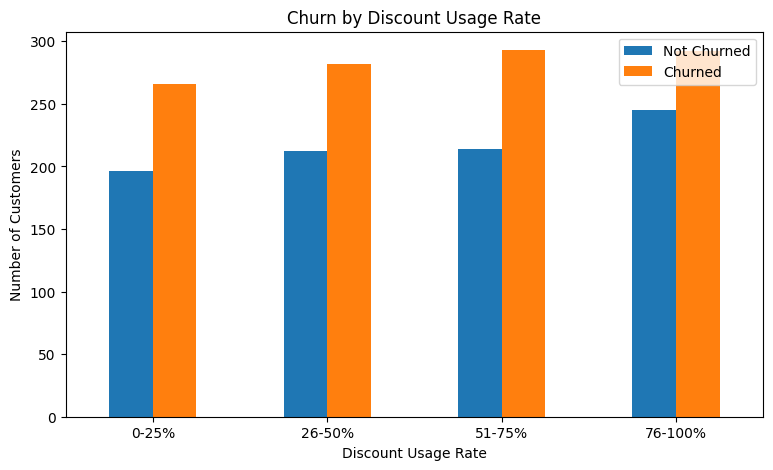

In [64]:
# Churn by Discount Usage Rate

df["DiscountGroup"] = pd.cut(
    df["DiscountUsageRate"],
    bins=[-0.01, 25, 50, 75, 100],
    labels=[
        "0-25%",
        "26-50%",
        "51-75%",
        "76-100%"
    ]
)

discount_churn = pd.crosstab(
    df["DiscountGroup"],
    df["Churned"]
)

print(discount_churn)

discount_churn.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Churn by Discount Usage Rate")
plt.xlabel("Discount Usage Rate")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.legend(["Not Churned", "Churned"])
plt.show()

Churned                0          1
DiscountGroup                      
0-25%          42.424242  57.575758
26-50%         42.914980  57.085020
51-75%         42.209073  57.790927
76-100%        45.623836  54.376164


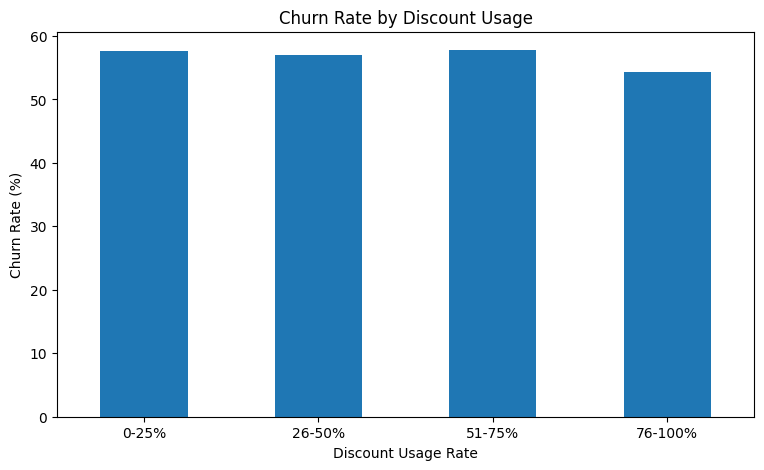

In [65]:
# Churn Rate by Discount Usage

discount_churn_rate = pd.crosstab(
    df["DiscountGroup"],
    df["Churned"],
    normalize="index"
) * 100

print(discount_churn_rate)

discount_churn_rate[1].plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Churn Rate by Discount Usage")
plt.xlabel("Discount Usage Rate")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()

In [66]:
# Correlation Analysis

numeric_columns = [
    "Age",
    "MembershipDuration",
    "AvgMonthlySpend",
    "NumPurchasesLast3Months",
    "SupportTicketsRaised",
    "DiscountUsageRate",
    "LastPurchaseDaysAgo",
    "Churned"
]

correlation = df[numeric_columns].corr()

print(correlation["Churned"].sort_values(ascending=False))

Churned                    1.000000
LastPurchaseDaysAgo        0.181794
SupportTicketsRaised       0.040770
AvgMonthlySpend            0.026140
MembershipDuration         0.008371
Age                       -0.012101
DiscountUsageRate         -0.013082
NumPurchasesLast3Months   -0.047080
Name: Churned, dtype: float64


In [67]:
# Prepare Data for Machine Learning

features = [
    "Age",
    "MembershipDuration",
    "AvgMonthlySpend",
    "NumPurchasesLast3Months",
    "SupportTicketsRaised",
    "DiscountUsageRate",
    "LastPurchaseDaysAgo"
]

X = df[features]
y = df["Churned"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nFeatures:")
print(X.head())

Features shape: (2000, 7)
Target shape: (2000,)

Features:
   Age  MembershipDuration  AvgMonthlySpend  NumPurchasesLast3Months  \
0   56                  17           189.05                        2   
1   69                  44           387.53                        3   
2   46                  56           174.29                        4   
3   32                  28           514.01                        4   
4   60                  29           412.37                        5   

   SupportTicketsRaised  DiscountUsageRate  LastPurchaseDaysAgo  
0                     3              43.64                   95  
1                     2              65.48                   69  
2                     1              70.03                  114  
3                     2              86.31                  104  
4                     2              18.05                  108  


In [68]:
# Split Data into Training and Testing Sets

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Features:", X_train.shape)
print("Testing Features:", X_test.shape)
print("Training Target:", y_train.shape)
print("Testing Target:", y_test.shape)

Training Features: (1600, 7)
Testing Features: (400, 7)
Training Target: (1600,)
Testing Target: (400,)


In [69]:
# Logistic Regression Model

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

logistic_model = LogisticRegression(max_iter=1000)

logistic_model.fit(X_train, y_train)

y_pred_logistic = logistic_model.predict(X_test)

accuracy_logistic = accuracy_score(y_test, y_pred_logistic)

print("Logistic Regression Accuracy: {:.2f}%".format(
    accuracy_logistic * 100
))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_logistic))

Logistic Regression Accuracy: 57.25%

Classification Report:
              precision    recall  f1-score   support

           0       0.51      0.33      0.40       173
           1       0.60      0.76      0.67       227

    accuracy                           0.57       400
   macro avg       0.55      0.54      0.53       400
weighted avg       0.56      0.57      0.55       400



In [70]:
# Random Forest Model

from sklearn.ensemble import RandomForestClassifier

random_forest = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

random_forest.fit(X_train, y_train)

y_pred_rf = random_forest.predict(X_test)

accuracy_rf = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy: {:.2f}%".format(
    accuracy_rf * 100
))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 49.25%

Classification Report:
              precision    recall  f1-score   support

           0       0.39      0.31      0.34       173
           1       0.55      0.63      0.59       227

    accuracy                           0.49       400
   macro avg       0.47      0.47      0.46       400
weighted avg       0.48      0.49      0.48       400



Confusion Matrix:
[[ 57 116]
 [ 55 172]]


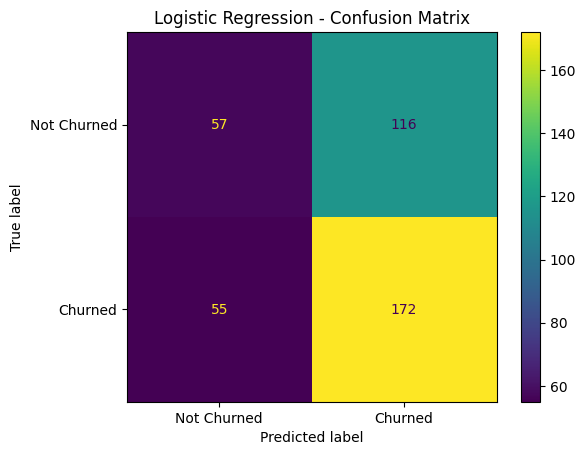

In [71]:
# Confusion Matrix - Logistic Regression

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_logistic)

print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Churned", "Churned"]
)

disp.plot()
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

In [72]:
# Scaled Logistic Regression

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

scaled_logistic_model = LogisticRegression(max_iter=1000)

scaled_logistic_model.fit(X_train_scaled, y_train)

y_pred_scaled = scaled_logistic_model.predict(X_test_scaled)

accuracy_scaled = accuracy_score(y_test, y_pred_scaled)

print("Scaled Logistic Regression Accuracy: {:.2f}%".format(
    accuracy_scaled * 100
))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_scaled))

Scaled Logistic Regression Accuracy: 57.00%

Classification Report:
              precision    recall  f1-score   support

           0       0.50      0.32      0.39       173
           1       0.60      0.76      0.67       227

    accuracy                           0.57       400
   macro avg       0.55      0.54      0.53       400
weighted avg       0.56      0.57      0.55       400



In [73]:
# Logistic Regression Feature Coefficients

feature_importance = pd.DataFrame({
    "Feature": features,
    "Coefficient": logistic_model.coef_[0]
})

feature_importance["Absolute_Coefficient"] = (
    feature_importance["Coefficient"].abs()
)

feature_importance = feature_importance.sort_values(
    "Absolute_Coefficient",
    ascending=False
)

print(feature_importance)

                   Feature  Coefficient  Absolute_Coefficient
4     SupportTicketsRaised     0.090920              0.090920
3  NumPurchasesLast3Months    -0.043705              0.043705
6      LastPurchaseDaysAgo     0.007344              0.007344
0                      Age    -0.002566              0.002566
1       MembershipDuration     0.002140              0.002140
5        DiscountUsageRate    -0.000184              0.000184
2          AvgMonthlySpend     0.000143              0.000143


                   Feature  Coefficient  Absolute_Coefficient
5        DiscountUsageRate    -0.005299              0.005299
2          AvgMonthlySpend     0.021257              0.021257
1       MembershipDuration     0.037104              0.037104
0                      Age    -0.039231              0.039231
3  NumPurchasesLast3Months    -0.094359              0.094359
4     SupportTicketsRaised     0.116755              0.116755
6      LastPurchaseDaysAgo     0.378375              0.378375


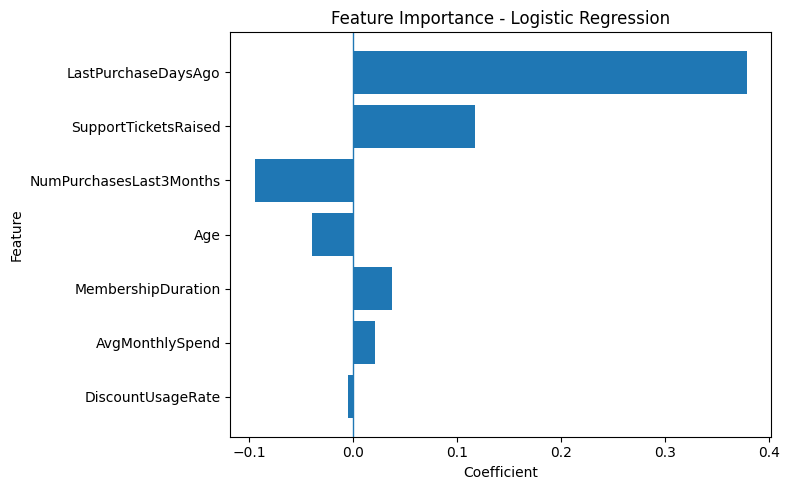

In [74]:
# Feature Importance using Scaled Logistic Regression

scaled_feature_importance = pd.DataFrame({
    "Feature": features,
    "Coefficient": scaled_logistic_model.coef_[0]
})

scaled_feature_importance["Absolute_Coefficient"] = (
    scaled_feature_importance["Coefficient"].abs()
)

scaled_feature_importance = scaled_feature_importance.sort_values(
    "Absolute_Coefficient",
    ascending=True
)

print(scaled_feature_importance)

# Plot feature importance
plt.figure(figsize=(8, 5))

plt.barh(
    scaled_feature_importance["Feature"],
    scaled_feature_importance["Coefficient"]
)

plt.axvline(0, linewidth=1)
plt.title("Feature Importance - Logistic Regression")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

Logistic Regression AUC: 0.6
Random Forest AUC: 0.495


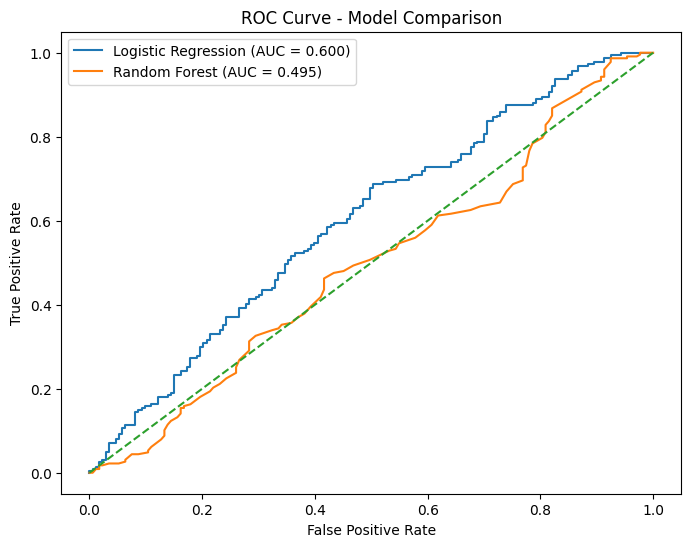

In [75]:
# ROC Curve and AUC Comparison

from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Get prediction probabilities
y_prob_logistic = logistic_model.predict_proba(X_test)[:, 1]
y_prob_rf = random_forest.predict_proba(X_test)[:, 1]

# Calculate ROC curves
fpr_logistic, tpr_logistic, _ = roc_curve(y_test, y_prob_logistic)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

# Calculate AUC
auc_logistic = roc_auc_score(y_test, y_prob_logistic)
auc_rf = roc_auc_score(y_test, y_prob_rf)

print("Logistic Regression AUC:", round(auc_logistic, 3))
print("Random Forest AUC:", round(auc_rf, 3))

# Plot ROC curves
plt.figure(figsize=(8, 6))

plt.plot(
    fpr_logistic,
    tpr_logistic,
    label=f"Logistic Regression (AUC = {auc_logistic:.3f})"
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest (AUC = {auc_rf:.3f})"
)

plt.plot([0, 1], [0, 1], linestyle="--")

plt.title("ROC Curve - Model Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

In [76]:
# Model Performance Comparison

model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Scaled Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_logistic,
        accuracy_scaled,
        accuracy_rf
    ],
    "AUC": [
        auc_logistic,
        roc_auc_score(y_test, y_prob_logistic),
        auc_rf
    ]
})

model_comparison["Accuracy (%)"] = model_comparison["Accuracy"] * 100

print(model_comparison[["Model", "Accuracy (%)", "AUC"]])

                        Model  Accuracy (%)       AUC
0         Logistic Regression         57.25  0.599908
1  Scaled Logistic Regression         57.00  0.599908
2               Random Forest         49.25  0.494640


In [77]:
# Select the Best Model

best_model = logistic_model

print("Best Model: Logistic Regression")
print(f"Accuracy: {accuracy_logistic * 100:.2f}%")
print(f"AUC: {auc_logistic:.3f}")

Best Model: Logistic Regression
Accuracy: 57.25%
AUC: 0.600


In [78]:
# Key Business Insights

print("===== KEY CHURN INSIGHTS =====")

# 1. Overall churn rate
print(f"Overall Churn Rate: {churn_rate:.2f}%")

# 2. Highest churn by age group
age_churn_rate = pd.crosstab(
    df["AgeGroup"],
    df["Churned"],
    normalize="index"
) * 100

highest_age_group = age_churn_rate[1].idxmax()
highest_age_rate = age_churn_rate[1].max()

print(f"Highest Churn Age Group: {highest_age_group}")
print(f"Churn Rate: {highest_age_rate:.2f}%")

# 3. Highest churn by membership duration
membership_churn_rate = pd.crosstab(
    df["MembershipGroup"],
    df["Churned"],
    normalize="index"
) * 100

highest_membership_group = membership_churn_rate[1].idxmax()
highest_membership_rate = membership_churn_rate[1].max()

print(f"Highest Churn Membership Group: {highest_membership_group}")
print(f"Churn Rate: {highest_membership_rate:.2f}%")

# 4. Highest churn by purchase recency
recency_churn_rate = pd.crosstab(
    df["PurchaseRecencyGroup"],
    df["Churned"],
    normalize="index"
) * 100

highest_recency_group = recency_churn_rate[1].idxmax()
highest_recency_rate = recency_churn_rate[1].max()

print(f"Highest Churn Recency Group: {highest_recency_group}")
print(f"Churn Rate: {highest_recency_rate:.2f}%")

# 5. Highest churn by discount usage
discount_churn_rate = pd.crosstab(
    df["DiscountGroup"],
    df["Churned"],
    normalize="index"
) * 100

highest_discount_group = discount_churn_rate[1].idxmax()
highest_discount_rate = discount_churn_rate[1].max()

print(f"Highest Churn Discount Group: {highest_discount_group}")
print(f"Churn Rate: {highest_discount_rate:.2f}%")

===== KEY CHURN INSIGHTS =====
Overall Churn Rate: 56.65%
Highest Churn Age Group: 36-45
Churn Rate: 60.26%
Highest Churn Membership Group: 0-6 Months
Churn Rate: 58.62%
Highest Churn Recency Group: 91-180 Days
Churn Rate: 63.43%
Highest Churn Discount Group: 51-75%
Churn Rate: 57.79%


In [79]:
# Final Model Summary

print("===== FINAL MODEL SUMMARY =====")

print("\nBest Model:")
print("Logistic Regression")

print(f"\nAccuracy: {accuracy_logistic * 100:.2f}%")
print(f"AUC: {auc_logistic:.3f}")

print("\nKey Findings:")
print(f"1. Overall churn rate: {churn_rate:.2f}%")
print(f"2. Highest churn age group: {highest_age_group} ({highest_age_rate:.2f}%)")
print(f"3. Highest churn membership group: {highest_membership_group} ({highest_membership_rate:.2f}%)")
print(f"4. Highest churn recency group: {highest_recency_group} ({highest_recency_rate:.2f}%)")
print(f"5. Highest churn discount group: {highest_discount_group} ({highest_discount_rate:.2f}%)")
print(f"6. Most influential feature: LastPurchaseDaysAgo")

===== FINAL MODEL SUMMARY =====

Best Model:
Logistic Regression

Accuracy: 57.25%
AUC: 0.600

Key Findings:
1. Overall churn rate: 56.65%
2. Highest churn age group: 36-45 (60.26%)
3. Highest churn membership group: 0-6 Months (58.62%)
4. Highest churn recency group: 91-180 Days (63.43%)
5. Highest churn discount group: 51-75% (57.79%)
6. Most influential feature: LastPurchaseDaysAgo


# Business Recommendations

Based on the exploratory data analysis and machine learning results, the following strategies can help reduce customer churn:

### 1. Target Customers with Long Purchase Gaps
Customers who have not purchased for 91–180 days have the highest churn rate (63.43%).  
The company should use personalized offers, reminders, and re-engagement campaigns to bring these customers back.

### 2. Focus on New Members
Customers with 0–6 months of membership show a high churn rate (58.62%).  
The company should improve onboarding, provide early-stage support, and offer incentives during the first few months.

### 3. Monitor Customers Aged 36–45
The 36–45 age group has the highest churn rate among the analyzed age groups (60.26%).  
Targeted loyalty programs and personalized communication could improve retention.

### 4. Improve Customer Support
Support tickets are positively associated with churn.  
The company should identify customers with repeated support issues and resolve their problems quickly.

### 5. Use Purchase Recency as an Early Warning Signal
`LastPurchaseDaysAgo` is the most influential feature in the Logistic Regression model.  
Customers with increasing purchase gaps should be flagged as potential churn risks.

### 6. Use Predictive Modeling for Retention
The Logistic Regression model achieved an accuracy of 57.25% and an AUC of 0.600.  
Although the model is not highly accurate, it demonstrates that customer behavior can be used to identify potential churn risks.

# Conclusion

This project analyzed customer churn using exploratory data analysis and machine learning.

The analysis found that the overall customer churn rate is **56.65%**. Customers with a longer period since their last purchase showed substantially higher churn, making purchase recency an important indicator of customer retention risk.

Among the tested machine learning models, **Logistic Regression** performed best, achieving **57.25% accuracy** and an **AUC of 0.600**. The feature analysis also identified `LastPurchaseDaysAgo` as the most influential feature in the model.

The results suggest that businesses can reduce churn by identifying customers with long purchase gaps, improving onboarding for new members, addressing repeated support issues, and using targeted retention campaigns.

Overall, this project demonstrates how **Python, Pandas, Matplotlib, Seaborn, and Scikit-learn** can be used to transform customer data into actionable business insights and build a basic predictive churn model.

## Project Outcome

- Data cleaning and preprocessing completed
- Exploratory data analysis completed
- Customer churn patterns identified
- Correlation analysis completed
- Multiple machine learning models evaluated
- Model performance compared using Accuracy and AUC
- Feature importance analyzed
- Business recommendations developed
- Final conclusions documented